In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spoti.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           85000 non-null  object

                mean  count
genre                      
Pop        48.367108   7096
R&B        48.364342   7084
Classical  48.364208   7158
Hip-Hop    48.357402   7160
EDM        48.204961   6894
Metal      48.193611   7200
Country    48.170839   7030
Indie      48.124162   7007
Folk       48.103107   7080
Rock       47.968508   7113


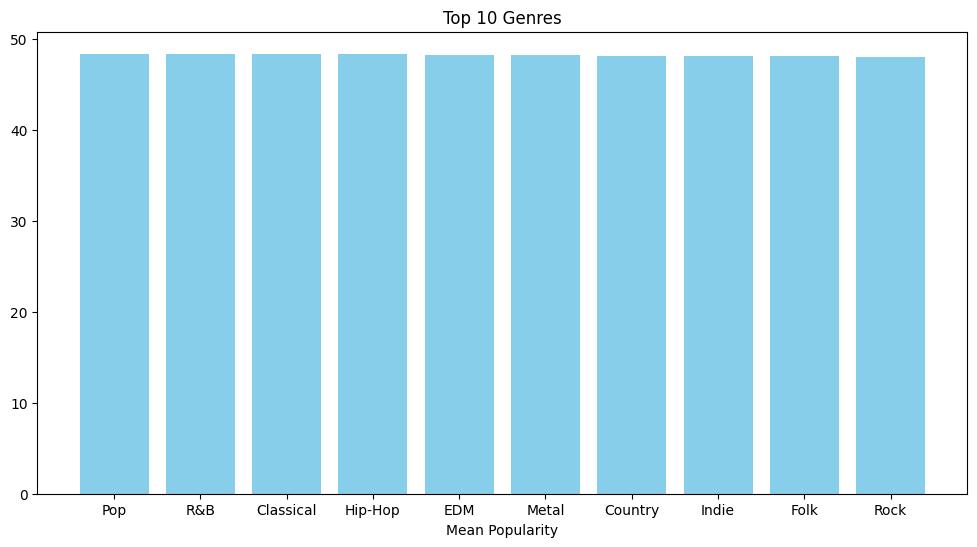

In [4]:
genre_popularity = df.groupby('genre')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(genre_popularity.head(10))
# Visualize the genre popularity
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(genre_popularity.index[:10], genre_popularity['mean'][:10], color='skyblue')
plt.xlabel('Mean Popularity')
plt.title('Top 10 Genres')
plt.show()

In [5]:
#Released date month vs popularity show in line plot for pop songs in 2024
pop_songs_2024 = pop_songs[pop_songs['release_date'].dt.year == 2024]
pop_songs_2024['release_month'] = pop_songs_2024['release_date'].dt.to_period('M')
monthly_popularity_2024 = pop_songs_2024.groupby('release_month')['popularity'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_popularity_2024.index.astype(str), monthly_popularity_2024.values, marker='o', color='skyblue')
plt.xlabel('Release Month')
plt.ylabel('Average Popularity')
plt.title('Average Popularity of Pop Songs by Release Month (2024)')
plt.xticks(rotation=45)
plt.grid()
plt.show()


NameError: name 'pop_songs' is not defined

In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month
plt.figure(figsize=(10,6))
df.groupby('release_month')['popularity'].mean().plot(kind='line', marker='o', color='teal')
plt.title('Popularity Trend by Release Month')
plt.ylabel('Average Popularity')
plt.xlabel('Release Month')
plt.xticks(range(1,13))
plt.show()

In [ ]:
#popularity pop songs based on country
pop_songs = df[df['genre'] == 'Pop']
pop_songs_country = pop_songs.groupby('country')['popularity'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(pop_songs_country.index, pop_songs_country.values)
plt.xticks(rotation=90)
plt.ylim(40, 52)
plt.yticks(range(40, 53, 1))
plt.title('Average Popularity of Pop Songs by Country')
plt.xlabel('Country')
plt.ylabel('Average Popularity')
plt.show()

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           85000 non-null  object

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [8]:
kolom = ['tempo', 'energy', 'duration_ms', 'danceability']
X = df[kolom]
y = df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
sample = pd.DataFrame([{
    'tempo': 150,
    'energy': 20,
    'duration_ms': 1800,
    'danceability': 10
}])

sample = sample.reindex(columns=X.columns, fill_value=0)
predicted_popularity = model.predict(sample)
print('Predicted popularity:', predicted_popularity[0])

Predicted popularity: 46.04295284977477
